# Notebook Overview
1. What spatial niches exist within each lesion?
2. Are the same niches present in both lesions?
3. What cell types define each niche?

In [ ]:
!pip install scanpy squidpy numpy pandas matplotlib seaborn cellcharter lightning scikit-learn AnnData

In [ ]:
# -- Imports
import os
import scanpy as sc
import squidpy as sq
import anndata as ad
import numpy as np
import pandas as pd
import seaborn as sns
import cellcharter as cc
import matplotlib.pyplot as plt
from lightning.pytorch import seed_everything
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

In [ ]:
# -- SET THE SEED
seed_everything(3)

INFO: Seed set to 3
INFO:lightning.fabric.utilities.seed:Seed set to 3


3

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
# -- Paths
input_path_BEME_346 = "/content/drive/MyDrive/endo-immune-atlas/data/processed/BEME346_spatial_immunosenescence.h5ad"

input_path_BEME_355G = "/content/drive/MyDrive/endo-immune-atlas/data/processed/BEME355G_spatial_immunosenescence.h5ad"

output_path_data = "/content/drive/MyDrive/endo-immune-atlas/data/processed"
output_path_figures = "/content/drive/MyDrive/endo-immune-atlas/results/final_figures"

os.makedirs(output_path_figures, exist_ok=True)

In [ ]:
# -- Import objects
adata_346 = sc.read_h5ad(input_path_BEME_346)
adata_355G = sc.read_h5ad(input_path_BEME_355G)

Since the goal is to compare the neighborhoods between the tissue samples, the tissue objects will be grouped together to make sure that Niche 1 in 346 is the same niche in 355G. This also will make life easier if more tissues are added to the analysis pipeline.

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# FUNCTION_10_1 -- PREP AND CLEAN OBJECT BEFORE ANALYSIS
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

def prepare_cellcharter_adata(adata):

  """
  Creates a copy of a spatial AnnData object. Keeps the original AnnData unchanged

  Parameters:
  adata: AnnData
    Full spatial AnnData object

  Returns:
  AnnData
    A copy containing only CellCharter relevant obsm representations
  """

  adata_cc = adata.copy()

    # representations needed for CellCharter workflow
  keep_obsm = [
      "spatial_connectivities",
      "spatial",
      "immune_abundance",
      "immune_abundance_scaled",
      'q05_cell_abundance_w_sf'
      ]

  for key in list(adata_cc.obsm.keys()):
      if key not in keep_obsm:
          del adata_cc.obsm[key]

  return adata_cc

In [ ]:
# -- Make CC copies
adata_346_cc = prepare_cellcharter_adata(adata_346)
adata_355G_cc = prepare_cellcharter_adata(adata_355G)

In [ ]:
#============================================================================
# TISSUE DICT - update this when more tissues for analysis
#============================================================================
adatas = {
    "BEME346": adata_346_cc,
    "BEME355G": adata_355G_cc,
}

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# FUNCTION_10_1 -- ADD METADATA TO OBS BEFORE MERGING
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

def add_metadata(adata,
                 sample_id,
                 tissue_type=None,
                 lesion_site=None):

  """
  Adds sample metadata to the object to allow for batching when analyzing niches downstream.

  Parameters:
  adata : AnnData
    The spatial objects that metadata will be appended to
  sample_id: str
    The sample names for each tissue/spatial sample
  tissue_type: str
    The tissue type of the sample
  lesion_site: str
    The lesion site in which the sample was taken from. Leave as none if samples are from healthy tissues.

  Output:
  adata: AnnData
  """
  adata.obs["sample_id"] = sample_id

  if tissue_type is not None:
    adata.obs["tissue_type"] = tissue_type

  if lesion_site is not None:
    adata.obs["lesion_site"] = lesion_site

  return adata


In [ ]:
# -- ADDING METADATA TO TISSUE OBJECTS
adata_346 = add_metadata(adata_346,
                         sample_id="BEME_346",
                         tissue_type="endometriosis",
                         lesion_site="peritoneal"
                         )

adata_355G = add_metadata(adata_355G,
                         sample_id="BEME_355G",
                         tissue_type="endometriosis",
                         lesion_site="peritoneal")

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# FUNCTION_10_2 -- ADD ABUNDANCES FROM CELL2LOCATION
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

def add_immune_abundance(adata,
                         key="q05_cell_abundance_w_sf",
                         cell_types= "immune_cell_types",):

  """
  Cleans the immune abundance columns by matching cell types to their immune abundance values from cell2location and converts from a pandas DataFrame into a NumPy array for downstream analysis.

  Parameters:
  adata : AnnData
    The spatial objects for analysis

  cell_types: str
    The column that has cell type labels
  key: str
    The label name of the column that holds the immune abundance values from cell2location

  Output:
  adata: AnnData
  """

  immune = (adata.obsm[key]
                      .copy()
                      )

  adata.uns[cell_types] = (immune
                           .columns
                           .tolist()
                           )

  adata.obsm["immune_abundance"] = (immune.to_numpy())

  return adata

In [ ]:
# -- Clean up labels for CC & add immune_abundances
for adata in adatas.values():
  add_immune_abundance(adata)

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# FUNCTION_10_3 -- CONCAT TISSUE OBJECTS
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
def concat_samples(adatas):

    processed = []

    for sample_id, a in adatas.items():

        # copy
        a = a.copy()

        # make unique within sample
        a.obs_names_make_unique()

        # add sample prefix
        a.obs_names = [
            f"{sample_id}_{spot}"
            for spot in a.obs_names
        ]
        a.obs["sample_id"] = sample_id

        print(sample_id, a.obs_names[:3])

        processed.append(a)

    adata_concat = ad.concat(
        processed,
        join="outer",
        label="sample_id",
        keys=list(adatas.keys()),
        uns_merge="unique"
    )

    return adata_concat

In [ ]:
# -- Concat samples
adata_immune = concat_samples(adatas)

BEME346 Index(['BEME346_AAACAGTGTTCCTGGG-1', 'BEME346_AAACCGTTCGTCCAGG-1',
       'BEME346_AAACTGCTGGCTCCAA-1'],
      dtype='object')
BEME355G Index(['BEME355G_AAACAGAGCGACTCCT-1', 'BEME355G_AAACAGCTTTCAGAAG-1',
       'BEME355G_AAACAGGGTCTATATT-1'],
      dtype='object')


In [ ]:
# -- SCALE DATA FOR MODELING
adata_immune.obsm["immune_abundance_scaled"] = (
    StandardScaler().fit_transform(
        adata_immune.obsm["immune_abundance"]
    )
)

print(f"Finished scaling immune abundances.")

Finished scaling immune abundances.


In [ ]:
# -- BUILD SPATIAL NEIGHBORS
adata_immune.obs["sample_id"] = (
    adata_immune.obs["sample_id"]
    .astype("category")
)

sq.gr.spatial_neighbors(
    adata_immune,
    coord_type="grid",
    n_neighs=6,
    library_key="sample_id"
)

INFO     Creating graph using `None` transform and `2` libraries.                                                  


/tmp/ipykernel_15342/111741718.py:7: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(


In [ ]:
# -- Remove biologically unrealistic long connections
cc.gr.remove_long_links(
    adata_immune
)

In [ ]:
#-- AGGREGATE NEIGHBORS
cc.gr.aggregate_neighbors(
    adata_immune,
    use_rep="immune_abundance_scaled",
    n_layers=3
)

  0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
for k in adata_immune.obsm.keys():
    print(k, adata_immune.obsm[k].shape)

q05_cell_abundance_w_sf (3348, 11)
spatial (3348, 2)
immune_abundance (3348, 11)
immune_abundance_scaled (3348, 11)
X_cellcharter (3348, 44)


In [ ]:
# -- AUTOMATICALLY CHOOSE THE NUMBER OF NICHES
autok = cc.tl.ClusterAutoK(
    n_clusters=(3, 8)
)

autok.fit(
    adata_immune,
    use_rep="X_cellcharter"
)

Iteration 1/10


  0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Iteration 2/10


  0%|          | 0/8 [00:00<?, ?it/s]

Iteration 3/10


  0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Convergence with a change in stability of 0.009969109347043275 reached after 3 iterations


In [ ]:
adata_immune.obs["immune_niche"] = autok.predict(
    adata_immune,
    use_rep="X_cellcharter"
)

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


In [ ]:
adata_immune.obs["immune_niche"].value_counts()

,count
immune_niche,
3,728
0,665
7,604
1,575
4,400
6,247
2,108
5,21


In [ ]:
adata_immune.obs["immune_niche"].value_counts()

,count
immune_niche,
3,728
0,665
7,604
1,575
4,400
6,247
2,108
5,21


In [ ]:
adata_immune.obs.groupby("immune_niche")["sample_id"].value_counts()

/tmp/ipykernel_15342/1425311964.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_immune.obs.groupby("immune_niche")["sample_id"].value_counts()


immune_niche  sample_id
0             BEME355G     665
              BEME346        0
1             BEME355G     535
              BEME346       40
2             BEME355G     108
              BEME346        0
3             BEME346      728
              BEME355G       0
4             BEME346      400
              BEME355G       0
5             BEME355G      21
              BEME346        0
6             BEME346      220
              BEME355G      27
7             BEME355G     604
              BEME346        0
Name: count, dtype: int64

In [ ]:
immune = pd.DataFrame(
    adata_immune.obsm["immune_abundance"],
    columns=[
        "Classical Monocytes",
        "Non-Classical Monocytes",
        "Tissue Resident Macrophages",
        "Dendritic cells",
        "CD16+ NK cells",
        "CD16- NK cells",
        "CD4 T cells",
        "CD8 T cells",
        "Tregs",
        "γδ T cells",
        "B cells"
    ]
)

immune["sample_id"] = adata_immune.obs["sample_id"].values

immune.groupby("sample_id").mean()

/tmp/ipykernel_15342/530944411.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  immune.groupby("sample_id").mean()


,Classical Monocytes,Non-Classical Monocytes,Tissue Resident Macrophages,Dendritic cells,CD16+ NK cells,CD16- NK cells,CD4 T cells,CD8 T cells,Tregs,γδ T cells,B cells
sample_id,,,,,,,,,,,
BEME346,2.182864,2.253990,5.189918,4.633639,1.485744,0.643977,1.604661,0.468436,0.433498,4.968487,1.501231
BEME355G,1.517583,3.804098,8.183191,6.829865,3.141739,2.131987,1.369505,1.423371,1.520569,5.022693,3.590021


In [ ]:
import pandas as pd

immune_df = pd.DataFrame(
    adata_immune.obsm["immune_abundance"],
    columns=[
        "Classical Monocytes",
        "Non-Classical Monocytes",
        "Tissue Resident Macrophages",
        "Dendritic cells",
        "CD16+ NK cells",
        "CD16- NK cells",
        "CD4 T cells",
        "CD8 T cells",
        "Tregs",
        "γδ T cells",
        "B cells"
    ],
    index=adata_immune.obs_names
)

# add CellCharter labels
immune_df["immune_niche"] = (
    adata_immune.obs["immune_niche"]
    .astype(str)
)

In [ ]:
niche_composition = (
    immune_df
    .groupby("immune_niche")
    .mean()
)

niche_composition

,Classical Monocytes,Non-Classical Monocytes,Tissue Resident Macrophages,Dendritic cells,CD16+ NK cells,CD16- NK cells,CD4 T cells,CD8 T cells,Tregs,γδ T cells,B cells
immune_niche,,,,,,,,,,,
0,0.928315,2.375621,5.882668,4.480131,1.950078,1.337084,0.788966,0.873487,0.978820,3.212811,2.235368
1,0.045259,0.118391,0.327736,0.254817,0.150104,0.052720,0.034389,0.033200,0.059113,0.154589,0.100335
2,5.580553,13.568934,27.342968,23.504025,11.189131,7.743552,5.184220,5.242139,5.149711,17.489054,12.732585
3,1.244231,2.605776,6.542329,5.999200,1.830317,0.820654,0.858297,0.411781,0.370072,6.435175,1.270113
4,5.166920,2.955418,5.804399,4.824172,1.743329,0.712121,3.893955,0.852166,0.780950,5.254565,2.817731
5,10.700908,25.613459,48.024017,44.099056,20.981356,14.652224,9.994955,10.190764,9.206998,33.914890,24.856821
6,0.253135,0.255841,0.597351,0.643092,0.173124,0.078523,0.203155,0.059780,0.105358,0.511846,0.182206
7,2.480816,6.276515,13.159891,11.211551,5.157799,3.489040,2.259389,2.325285,2.549296,8.280200,5.930607


In [ ]:
pd.crosstab(
    adata_immune.obs["immune_niche"],
    adata_immune.obs["tissue_level_immune_class"],
    normalize="index"
)

tissue_level_immune_class,Immune-poor,Immune-low,Immune-moderate,Immune-high
immune_niche,,,,
0,0.315789,0.494737,0.163910,0.025564
1,1.000000,0.000000,0.000000,0.000000
2,0.000000,0.009259,0.037037,0.953704
3,0.189560,0.104396,0.395604,0.310440
4,0.155000,0.022500,0.225000,0.597500
5,0.000000,0.000000,0.000000,1.000000
6,0.983806,0.004049,0.004049,0.008097
7,0.011589,0.221854,0.367550,0.399007


In [ ]:
adata_immune.obsm["immune_abundance_scaled"].std(axis=0)

array([0.99999964, 0.99999964, 1.0000002 , 1.0000002 , 1.        ,
       1.0000004 , 1.0000005 , 0.9999992 , 1.0000004 , 0.99999976,
       1.0000005 ], dtype=float32)

In [ ]:
immune_df["immune_niche"] = (
    adata_immune.obs["immune_niche"].astype(str)
)

celltype_by_niche = (
    immune_df
    .groupby("immune_niche")
    .mean()
)

global_mean = (
    immune_df
    .drop(columns="immune_niche")
    .mean()
)

celltype_enrichment = (
    celltype_by_niche
    .div(global_mean)
)

celltype_enrichment

,Classical Monocytes,Non-Classical Monocytes,Tissue Resident Macrophages,Dendritic cells,CD16+ NK cells,CD16- NK cells,CD4 T cells,CD8 T cells,Tregs,γδ T cells,B cells
immune_niche,,,,,,,,,,,
0,0.517630,0.751432,0.847373,0.756860,0.794263,0.882509,0.537811,0.850128,0.914874,0.642534,0.820603
1,0.025237,0.037448,0.047209,0.043048,0.061137,0.034796,0.023442,0.032312,0.055251,0.030916,0.036833
2,3.111730,4.291984,3.938635,3.970701,4.557312,5.110937,3.533904,5.101950,4.813281,3.497655,4.674126
3,0.693786,0.824232,0.942394,1.013487,0.745485,0.541652,0.585071,0.400768,0.345895,1.286978,0.466258
4,2.881087,0.934827,0.836098,0.814981,0.710055,0.470017,2.654375,0.829377,0.729931,1.050866,1.034388
5,5.966852,8.101781,6.917650,7.449966,8.545668,9.670832,6.813216,9.918236,8.605507,6.782677,9.124928
6,0.141148,0.080925,0.086046,0.108642,0.070513,0.051827,0.138484,0.058182,0.098475,0.102365,0.066888
7,1.383309,1.985322,1.895625,1.894047,2.100762,2.302853,1.540148,2.263101,2.382751,1.655966,2.177123


In [ ]:
pd.crosstab(
    adata_immune.obs["immune_niche"],
    adata_immune.obs["tissue_level_immune_class"],
    normalize="index"
).columns

CategoricalIndex(['Immune-poor', 'Immune-low', 'Immune-moderate',
                  'Immune-high'],
                 categories=['Immune-poor', 'Immune-low', 'Immune-moderate', 'Immune-high'], ordered=True, dtype='category', name='tissue_level_immune_class')

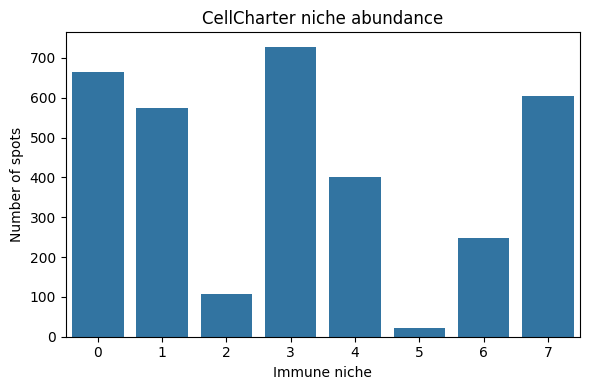

In [ ]:
niche_counts = (
    adata_immune.obs["immune_niche"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=niche_counts.index,
    y=niche_counts.values
)

plt.xlabel("Immune niche")
plt.ylabel("Number of spots")
plt.title("CellCharter niche abundance")

plt.tight_layout()
plt.show()

In [ ]:
immune_state_niche = pd.crosstab(
    adata_immune.obs["immune_niche"],
    adata_immune.obs["tissue_level_immune_class"],
    normalize="index"
)

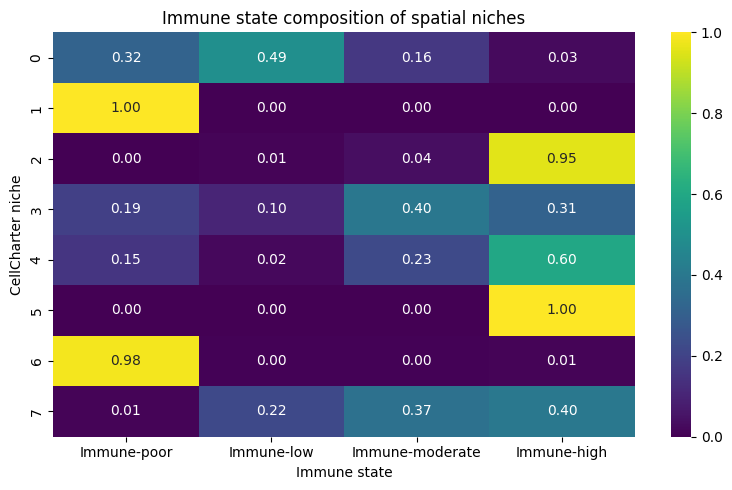

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    immune_state_niche,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

plt.xlabel("Immune state")
plt.ylabel("CellCharter niche")
plt.title("Immune state composition of spatial niches")

plt.tight_layout()
plt.show()

In [ ]:
immune_df = pd.DataFrame(
    adata_immune.obsm["immune_abundance"],
    columns=[
        "Classical Monocytes",
        "Non-Classical Monocytes",
        "Tissue Resident Macrophages",
        "Dendritic cells",
        "CD16+ NK cells",
        "CD16- NK cells",
        "CD4 T cells",
        "CD8 T cells",
        "Tregs",
        "γδ T cells",
        "B cells"
    ]
)

immune_df["immune_niche"] = (
    adata_immune.obs["immune_niche"]
    .astype(str)
    .values
)

In [ ]:
niche_celltype = (
    immune_df
    .groupby("immune_niche")
    .mean()
)

global_mean = (
    immune_df
    .drop(columns="immune_niche")
    .mean()
)

celltype_enrichment = (
    niche_celltype
    .div(global_mean)
)

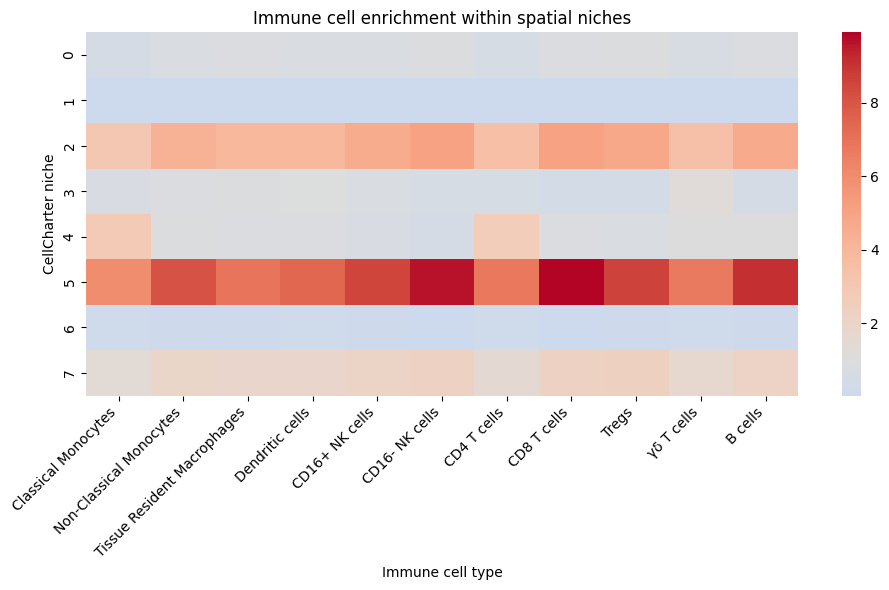

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    celltype_enrichment,
    cmap="coolwarm",
    center=1,
    annot=False
)

plt.xlabel("Immune cell type")
plt.ylabel("CellCharter niche")
plt.title("Immune cell enrichment within spatial niches")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

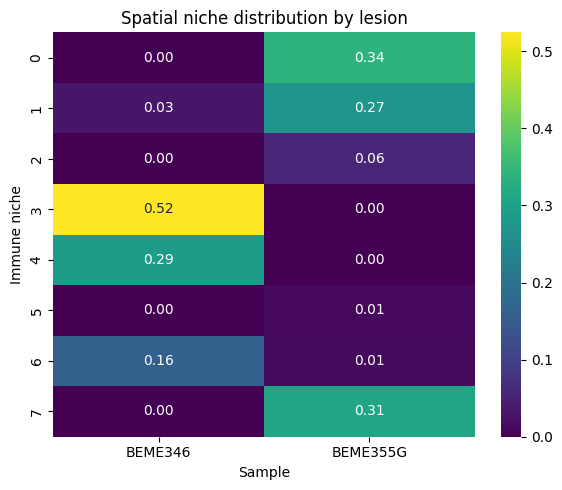

In [ ]:
niche_sample = pd.crosstab(
    adata_immune.obs["immune_niche"],
    adata_immune.obs["sample_id"],
    normalize="columns"
)

plt.figure(figsize=(6,5))

sns.heatmap(
    niche_sample,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

plt.xlabel("Sample")
plt.ylabel("Immune niche")
plt.title("Spatial niche distribution by lesion")

plt.tight_layout()
plt.show()

In [ ]:
adata_immune.uns["spatial"]["BEME346"] = (
    adata_immune.uns["spatial"].pop("BEME_346")
)

adata_immune.uns["spatial"]["BEME355G"] = (
    adata_immune.uns["spatial"].pop("BEME_355G")
)

In [ ]:
adata_immune.uns["spatial"].keys()

dict_keys(['BEME346', 'BEME355G'])

In [ ]:
adata_immune.obs["immune_niche"].value_counts()

,count
immune_niche,
3,728
0,665
7,604
1,575
4,400
6,247
2,108
5,21


In [ ]:
niche_labels = {
    "0": "Immune-depleted",
    "1": "Immune-cold",
    "2": "Diffuse immune",
    "3": "Myeloid-enriched",
    "4": "Monocyte-enriched",
    "5": "Immune hotspot",
    "6": "Immune-poor",
    "7": "Resting immune"
}

adata_immune.obs["immune_niche_label"] = adata_immune.obs["immune_niche"].astype(str).map(niche_labels)

In [ ]:
niche_palette = {
    "Immune-depleted": "#8C6D5A",  # warm taupe
    "Immune-cold": "#D9A441",  # muted gold
    "Diffuse immune": "#9B3A3A",  # deep terracotta/red
    "Myeloid-enriched": "#5C7A68",  # sage green
    "Monocyte-enriched": "#B56B8A",  # dusty rose
    "Immune hotspot": "#6B4C7A",  # muted plum
    "Immune-poor": "#4F6D8A",  # slate blue
    "Resting immune": "#C47A44",  # burnt orange
}
adata_immune.obs["immune_niche_label"] = adata_immune.obs["immune_niche_label"].astype("category")

categories = adata_immune.obs["immune_niche_label"].cat.categories.tolist()
adata_immune.uns["immune_niche_label_colors"] = [niche_palette[c] for c in categories]

fig = sq.pl.spatial_scatter(
    adata_immune,
    color="immune_niche_label",
    library_key="sample_id",
    spatial_key="spatial",
    size=2,
    img=False,
    ncols=2,
    figsize=(5,5),
    legend_loc=None,
    title=["BEME346 lesion", "BEME355G lesion"],
)



present_niches = set(adata_immune.obs["immune_niche"].astype(str).unique())
from matplotlib.patches import Patch

all_niches = ["0", "1", "2", "3", "4", "5", "6", "7"]
beme346_niches = set(adata_immune[adata_immune.obs["sample_id"] == "BEME346"].obs["immune_niche"].astype(str).unique())
beme355g_niches = set(adata_immune[adata_immune.obs["sample_id"] == "BEME355G"].obs["immune_niche"].astype(str).unique())
present_niches = beme346_niches | beme355g_niches

legend_elements = [
    Patch(facecolor=niche_palette[niche_labels[n]],
          label=niche_labels[n],
          alpha=1.0 if n in present_niches else 0.2)
    for n in all_niches
]

plt.gcf().legend(
    handles=legend_elements,
    loc="center right",
    title="Immune Niche",
    bbox_to_anchor=(1.05, 0.5)
)

plt.savefig(
    os.path.join(output_path_figures, "10_niche_discovery.png"),
    bbox_inches='tight',
    dpi=300
)
plt.close()

In [ ]:
# -- SAVE DATA
adata_immune.write_h5ad(
    os.path.join(output_path_data, "10_adata_immune_niches.h5ad")
)

niche_key = pd.DataFrame({
    "cluster": list(niche_labels.keys()),
    "label": list(niche_labels.values())
})

niche_key.to_csv(
    os.path.join(output_path_data, "10_immune_niche_labels.csv"),
    index=False
)